# Competitor Analysis Using Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System

## Business Context
Performing competitor analysis with a Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System.

## Problem Scenario
Conducting a robust competitor analysis of a company is a time-consuming and research-intensive process that may be prone to errors for example, outdated information.

Analysts spend significant time gathering data, identifying relevant competitors, and synthesizing insights into actionable recommendations.

## Objective
To address above mentioned challenges, a Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System is proposed.

This system will perform competitor analysis of a given company by comparing it with its key rivals in the relevant industry using the latest available web data.

Users will input a company name (e.g., "Tesla") and receive a well-structured report, comparing that company to its primary competitors (e.g., in the electric vehicle sector for Tesla), by leveraging a multi-agent collaborative architecture powered by RAG capabilities.

The system should deliver rapid, accurate, and actionable insights.

## Solution Approach

A Multi-Agent Retrieval-Augmented Generation (RAG) Collaborative System is implemented using a sequential workflow pattern.

This system automates competitor analysis by breaking down the task into distinct steps handled by specialized agents.

The sequential pattern ensures each step builds on the previous one. Also, incorporating RAG to retrieve and augment data from a vector database for context-aware insights.


**Below are the key components of the implementation:**

### State Management

The workflow uses a Pydantic-based state `CompetitiveAnalysisState` to track variables like company name, generated questions, search results, vectorstore status, and the final report.

### Tools
- `suggest_questions`: Generates relevant questions for competitor analysis using the LLM.
- `fetch_search_results`: Searches the web via Tavily API to fetch answers for the questions.
- `store_in_chromadb`: Stores question-answer pairs in ChromaDB for efficient retrieval.
- `generate_report`: Uses RAG to query the vectorstore and draft a structured report.




### Agents

- `Question Generator Agent`: Validates the company, identifies its sector, and generates analysis questions.

- `Data Retrieval and Storage Agent`: Fetches answers from the web and stores them in the vector database.

- `Report Drafter Agent`: Retrieves stored data via RAG and generates a professional, actionable report with sections like Executive Summary, Company Overview, Key Competitors, Strengths/Weaknesses, Market Strategies, and Recommendations.




### Workflow (Sequential Pattern)

The system uses LangGraph's StateGraph to define nodes for each agent.
Edges connect the nodes sequentially as indicated below.

`START → Question Generation → Data Retrieval/Storage → Report Drafting → END.`

The final output is formatted competitive analysis report, displayed in Markdown for readability.

# Installing the Libraries

Installing the libraries:
- **openai==1.99.9** → Official OpenAI client library for interacting with GPT models.  
- **langchain==0.3.27** → Core framework for building applications powered by LLMs.  
- **langchain-openai==0.3.30** → LangChain integration for OpenAI models.  
- **langchain-community==0.3.27** → Community-contributed LangChain modules (tools, integrations).  
- **langgraph==0.6.4** → Build and manage multi-step workflows or agent graphs for LLM-powered systems.  
- **langchain-chroma==0.2.5** → Connector for using **ChromaDB** as a vector database with LangChain.  
- **chromadb==1.0.16** → Open-source vector database for storing and retrieving embeddings.  
- **langchain-tavily==0.2.11** → Integration for the **Tavily API** (specialized web search + retrieval for RAG).  

In [9]:
#Install required packages
!pip install -q openai==1.99.9 \
                langchain==0.3.27 \
                langchain-openai==0.3.30 \
                langchain-community==0.3.27 \
                langgraph==0.6.4 \
                langchain-chroma==0.2.5 \
                chromadb==1.0.16 \
                langchain-tavily==0.2.11

# Setting up the Environment

## **Importing the relevant packages**

In [10]:
import os
import json
import random
import datetime

from typing import TypedDict, List, Optional, Dict, Tuple

from pydantic import BaseModel, Field,ConfigDict

import chromadb

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import StructuredTool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.retrievers import BaseRetriever
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent
from langchain_tavily import TavilySearch

from IPython.display import Image, display, Markdown

from google.colab import userdata

## **Instantiating the required variables**

Set the environment variables.

To securely connect with external APIs (like OpenAI and Tavily), we’ll set up our **environment variables**.  
This ensures our API keys are not hard-coded directly in the notebook, keeping them safe.

- **OPENAI_API_KEY**
- **OPENAI_BASE_URL**
- **TAVILY_API_KEY**

After running this cell, your notebook will be able to access both **OpenAI** and **Tavily APIs** securely.


In [11]:
# Set environment variables
os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')
os.environ['OPENAI_BASE_URL'] = "https://aibe.mygreatlearning.com/openai/v1"

Now that our environment variables are set, let's initialize the **core models** we'll use in this project:

Instantiating the LLM and the embedding model using the `ChatOpenAI` and `OpenAIEmbeddings` methods respectively.

In [12]:
#Omitting the explicit API keys and Base URLs since those are
#fetched by Open AI Automatically via the OS Envrion Variables
llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0
)

# Initialize OpenAIEmbeddings for generating text embeddings
embedding_model = OpenAIEmbeddings(
    model='text-embedding-3-small'
)

To enable **Retrieval-Augmented Generation (RAG)**, we need a place to store and query text embeddings.  
Here, we'll use **ChromaDB**, an open-source vector database.

Setting up the Chroma vector database client and a Chroma vector store collection for storing and retrieving search results.

In [13]:
# ChromaDB set up Persistent client
chromadb_client = chromadb.PersistentClient(path="./assist_db")

# Set up vectorstore
vectorstore = Chroma(
    collection_name="search_result_collection",
    collection_metadata={"hnsw:space": "cosine"},
    embedding_function=embedding_model,
    client=chromadb_client,
    persist_directory="./assist_db"
)


# **State Definitions**

Lets define the Pydantic models for structured outputs - 'QuestionSuggestion' and the overall state - 'CompetitiveAnalysisState'  .
State Definition ensure type safety and structure the data passed between agents and nodes.

## **QuestionSuggestion**


This model will help ensure that the responses from the LLM follow a **consistent format**, making them easier to validate and use later.

- Create a class that inherits from `BaseModel`.  
- Fields include:
  - **sector** → The industry sector of the company.  
  - **is_valid_company** →  A boolean flag for whether the company name is recognized.  
  - **questions** → A list of suggested competitive analysis questions.  
  - **error_message** → Optional field to capture any errors that occur.  

- The `Field()` argument ensures that **default values** and **descriptions** are available for each attribute.  


In [14]:
class QuestionSuggestion(BaseModel):
    """
    Structured output model for competitive analysis questions
    """
    sector: Optional[str] = Field(None, description="The industry sector the company operates in")

    is_valid_company: bool = Field(..., description="Whether the provided company name is valid/known")

    questions: List[str] = Field(default_factory=list,description="List of generated competitive analysis questions")

    error_message: Optional[str] = Field(None,description="Error message if any step fails")

## **Competitive Analysis State**

Next, we’ll create a state object for keeping track off the competitive analysis that keeps track of all the information our pipeline generates and updates during the competitive analysis workflow.

This will act as a “shared memory” object, making it easier to pass data between steps in the system.

- Fields include:
  - **company_name** → The company being analyzed.  
  - **max_num_of_questions** → The maximum number of questions to generate (use a constant as the default).  
  - **sector** → The industry sector (optional).  
  - **is_valid_company** → Boolean flag to mark if the company is recognized (optional).  
  - **question_list** → List of generated analysis questions (optional).  
  - **qna_results** → Stores answers to questions as a list of dictionaries (optional).  
  - **vectorstore** → Chroma vector database instance for retrieval.  
  - **chromadb_insert_status** → Tracks whether data was successfully stored in Chroma (optional).  
  - **report** → Final competitive analysis report (optional).  
  - **error_message** → Captures any error details (optional).

- The `model_config` setting allows **non-Pydantic types** (e.g., Chroma objects).


In [15]:
#Setting maximum limit to number of genetated questions
MAX_NUM_OF_QUESTIONS = 5

In [16]:
class CompetitiveAnalysisState(BaseModel):
    company_name: str
    max_num_of_questions: int = MAX_NUM_OF_QUESTIONS
    sector: Optional[str] = None
    is_valid_company: Optional[bool] = None
    question_list: Optional[List[str]] = None
    qna_results: Optional[List[Dict]] = None
    vectorstore: Chroma = vectorstore
    chromadb_insert_status: Optional[bool] = None
    report: Optional[str] = None
    error_message: Optional[str] = None
    model_config = ConfigDict(arbitrary_types_allowed=True)

# **Tools**

## **Tavily Search Tool**

To enrich our competitive analysis, **Tavily Search** will be used to fetch **relevant company information** that can later be embedded into our vector store and used for RAG.
The following code
- Initializes a `TavilySearch` instance with the following parameters:
  - **max_results** → The maximum number of results to return  
  - **include_answer** → Whether to include a synthesized answer from Tavily.  
  - **include_raw_content** → Whether to return raw page content along with the results.
  - **search_depth** → Set the level of search (`"basic"` or `"advanced"`).  

In [17]:
search = TavilySearch(max_results = 2,
                      include_answer=True,
                      include_raw_content=True,
                      search_depth="advanced")

Below section defines the tools used by the agents for,
- Suggesting questions,
- Fetching search results,
- Storing data in ChromaDB, and
- Generating the report.

## **Suggest Questions Tool**


The Suggest Questions Tool is a **custom LangChain tool** that uses an LLM to generate structured competitive analysis questions for a given company.  

This tool will serve as the **entry point** in our pipeline for validating company information and generating insightful prompts for deeper analysis.

The function `suggest_questions` contains a  **prompt** that instructs the LLM to:
     - Validate if the company is real/known.  
     - Identify its sector.  
     - Generate targeted competitor analysis questions (e.g., competitors, pricing, supply chain, strengths/weaknesses, market opportunities) and **invokes the LLM** with a structured output format (using the `QuestionSuggestion` model).  
The `@tool` decorator ensures that it can be called by agents within LangChain.


In [18]:
@tool
def suggest_questions(company_name: str, max_num_of_questions: int) -> str:
    """Suggest list containing questions for the given company name."""
    prompt = f"""
For the given company name: {company_name}

1. Validate if it's a known company: Set 'is_valid_company' to true if it's a recognized company; otherwise, false.
2. Identify its primary 'sector'.
3. Generate up to {max_num_of_questions} targeted questions for a comprehensive competitor analysis. Focus on areas that enable detailed comparisons and insights:
   - Identifying key competitors and market share.
   - Comparing products, pricing, technology, and supply chain.
   - Analyzing strengths, weaknesses, and differentiators (e.g., innovation, brand perception, customer service).
   - Exploring market trends, regulatory challenges, and growth opportunities.
   - Proposing strategies for outcompeting rivals (e.g., differentiation, partnerships, sustainability).
Ensure questions are specific, diverse, and actionable to support a structured report with sections like Executive Summary, Company Overview, Key Competitors, Strengths/Weaknesses, Market Strategies, and Recommendations.
"""
    print("[INSIDE TOOL] suggest_questions")
    try:
        # Invoke the LLM with structured output enforcement with the appropriate Pydantic model using the llm.with_structured_output method
        # This returns a Pydantic object (not raw text) if the model and wrapper support it

        result = llm.with_structured_output(QuestionSuggestion).invoke(prompt)

        print(f"[Identified SECTOR] {result.sector}")

        sector = str(result.sector)

        print(f"[IS VALID COMPANY] {result.is_valid_company}")

        is_valid_company = str(result.is_valid_company)

        print(f"[QUESTION GENERATED LIST] {result.questions}")

        questions_list = result.questions

        return json.dumps({
            "sector": sector,
            "is_valid_company": is_valid_company,
            "questions": questions_list
        })
    except Exception as e:

        print(f"Error: {str(e)}")

        return json.dumps({
            "sector": "",
            "is_valid_company": False,
            "questions": [],
            "error_message": str(e)
        })

## **Fetch Search Result Tool**

The Fetch Search Result tool will take each question, query the **Tavily Search API**, and collect the results.

The function **iterates** through the `question_list` and for each question:
     - Call `search.invoke({"query": question})` to get Tavily search results.  
     - Check if the result contains an `"answer"`.  
     - Store the pair (`question`, `answer`) in a list of dictionaries.  
Additionally, the function can:
- **Handle missing answers** by storing an empty string.
- Handle errors** with a `try/except` block and log them for debugging.  
- Return the **final results as a JSON string**.

In [19]:
@tool
def fetch_search_results(question_list: List[str]) -> str:
    """
    Iterate through 'question_list' and for each question, search for answers using the Tavily Search API.
    Output a JSON string containing a list of dictionaries with 'question' and 'answer'.
    """
    print("[INSIDE TOOL]: fetch_search_results")

    results = []

    # Itertate through the list of questions and process using the search tool
    for question in question_list:
        try:
            print("[QUESTION]:", question)

            # Invoke the Tavily search tool
            search_result = search.invoke({"query": question})

            print("[SEARCH RESULT]:", search_result)

            if 'answer' in search_result and search_result['answer']:
                answer = search_result['answer'].lower()
                print("[ANSWER TO BE STORED]:", answer)
                results.append({
                    "question": question,
                    "answer": answer
                })

            else:
                print("[WARNING]: No answer found for question", question)
                results.append({
                    "question": question,
                    "answer": ""
                })

        except Exception as e:
            print("[ERROR]:", str(e))
            results.append({
                "question": question,
                "answer": ""
            })

    return json.dumps(results)

## **Store in ChromaDB Tool**

After fetching question-answer pairs, they must be stored in **ChromaDB** so they can later be retrieved during the analysis.  
This tool will embed the answers and insert them into the vector store along with metadata for traceability.

The function `store_in_chromadb`:
- Loop through each question–answer dictionary.  
- **Skip empty answers** (don’t embed/store them).  
- For valid answers:  
    - Create a `documents` list containing the answer text.  
    - Create `metadatas` with fields such as:  
        - `question` → the original question  
        - `source_type` → `"answer"`  
        - `search_success` → whether a valid answer was found  
    - Create unique `ids` for each entry (e.g., `"doc_1"`, `"doc_2"`).  
- Use `vectorstore.add_texts()` to insert documents, metadata, and IDs into ChromaDB.  

In [20]:
@tool
def store_in_chromadb(qna_results: List[Dict]) -> str:
    """
    Stores a list of question-answer dictionaries in a ChromaDB vectorstore after embedding.
    Returns a JSON string indicating success or failure.
    """
    print("[INSIDE TOOL]: store_in_chromadb")
    success_count = 0
    # Iterate over the list containing qna results
    for index, d in enumerate(qna_results, start=1):
        try:

            question = d["question"]
            answer = d["answer"]

            search_success = bool(answer)
            if not answer:
                print(f"[WARNING]: Skipping empty answer for question: {question}")
                continue
            documents = [answer]
            metadatas = [{
                "question": question,
                "source_type": "answer",
                "search_success": search_success
            }]
            ids = [f"doc_{index}"]
            print("[DOCUMENTS]:", documents)
            print("[METADATA]:", metadatas)
            print("[IDS]:", ids)

            # Add documents, metadata and ids to the vectorstore using the .add_texts method
            vectorstore.add_texts(texts=documents, metadatas=metadatas, ids=ids)

            # Increase the success_count counter
            success_count += 1

            print(f"[SUCCESS]: Added entry for question: {question}")
        except Exception as e:

            print(f"[ERROR]: Failed to add entry for question '{d.get('question', '')}': {str(e)}")

    chromadb_insert_status = success_count == len([d for d in qna_results if d["answer"]])

    return json.dumps({"chromadb_insert_status": chromadb_insert_status})


## **Generate Report Tool**

The `generate_report` tool will be used to define precisely how to use retrieved context for generating the report by
- using the retrieved context as the primary source and comparing competitors across dimensions (market share, products, pricing, tech, supply chain, customer sentiment).
- highlighting differentiators and actionable strategies.
- structuring the final output into the named sections and citing context where relevant.

The functions builds a `human` message that requests a report for the given `company_name` and `sector` and includes a `{context}` placeholder which will be filled at runtime with retrieved documents from the vectorstore and combine messages into a `ChatPromptTemplate.from_messages([...])`

In [21]:
@tool
def generate_report(company_name: str, sector: str) -> str:
    """
    Generate a competitive analysis report using RAG from the vectorstore.
    Note: Vectorstore is accessed from the state in the node, not passed as an argument.
    """
    print("[INSIDE TOOL]: generate_report")
    prompt = ChatPromptTemplate.from_messages([
        ("system", """
Role: You are an advanced competitor analysis tool designed to generate detailed, data-driven insights on competing companies.
Your core function is to analyze competitors based on provided inputs (company name and sector) by leveraging retrieved context from a vector database (answers to targeted questions on competitors, market share, strengths/weaknesses, trends, etc.).
Instructions:
   - Use the provided context (question-answer pairs from web searches) as the primary source for all insights.
   - Perform in-depth comparisons (e.g., market share, product offerings, pricing, customer sentiment) by synthesizing relevant answers.
   - Highlight key differentiators (e.g., technological advantages, operational strengths, weaknesses) drawn from context.
   - Identify competitors' strengths to emulate or counter (e.g., brand loyalty, R&D investments) and weaknesses to exploit (e.g., customer service gaps, supply chain inefficiencies).
   - Propose actionable strategies (e.g., differentiation tactics, pricing adjustments, targeted marketing) based on analyzed data.
   - Compare competitors to uncover industry trends (e.g., emerging technologies, shifting consumer preferences) from context.
   - Synthesize findings into a comprehensive market strategy (e.g., whitespace opportunities, risk mitigation).
   - Prioritize recommendations based on competitive urgency (e.g., short-term wins vs. long-term positioning).
   - Structure the report with sections: Executive Summary, Company Overview, Key Competitors, Strengths and Weaknesses, Market Strategies, and Recommendations. Cite context where relevant.
"""),
    ("human", f"Generate report for {company_name} in the {sector} sector using retrieved context: {{context}}")
])
    return prompt  # Return the prompt template to be used in the node

# **Agents**

## **Initialize the Agents**

Below section creates reactive agents using LangChain's create_react_agent. Each agent is assigned specific tools:
- question_generator_agent: Uses suggest_questions tool.
- data_retrieval_storage_agent: Uses fetch_search_results and store_in_chromadb tool.
- report_drafter_agent: Uses generate_report tool.

### Questions Generator Agent

In [22]:
question_generator_agent = create_react_agent(llm, [suggest_questions])

### Data Retrieval & Storage Agent

In [23]:
data_retrieval_storage_agent = create_react_agent(llm, [fetch_search_results, store_in_chromadb])

### Report Drafter Agent

In [24]:
report_drafter_agent = create_react_agent(llm, [generate_report])

# **Defining the Nodes**

## **Question Generator Node**

Question Generator Node - Generates questions and updates state.

The run_question_generator node invokes the question-generation agent to produce structured JSON output and then parses that output to update the pipeline state by:
- invoking the agent with a short system+human message (company name, max questions) and retrieving the agent response.
- searching responses in reverse for the last JSON block (to find the structured payload) and using json.loads to parse it.
- updating CompetitiveAnalysisState fields: sector, is_valid_company, question_list, and error_message.
- handling errors and parsing failures gracefully by logging the issue and setting safe defaults (sector="", is_valid_company=False, question_list=[], error_message=<error>).
- returning the updated state for downstream nodes to consume.

In [25]:
def run_question_generator(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    print("[NODE]: run_question_generator")
    messages = [
        SystemMessage(content="Generate questions for competitive analysis."),
        HumanMessage(content=f"Company: {state.company_name}, Max questions: {state.max_num_of_questions}")
    ]
    try:
        # Invoke the question generator agent using the .invoke method
        response = question_generator_agent.invoke({"messages": messages})
        # Find the last message with valid JSON content
        last_message = None
        for msg in reversed(response["messages"]):
            if hasattr(msg, 'content') and isinstance(msg.content, str) and msg.content.strip().startswith('{'):
                last_message = msg.content
                break
        if last_message is None:
            last_message = response["messages"][-1].content if response["messages"] else ""
            print(f"[WARNING]: No valid JSON message found, using last message: {last_message}")

        try:
            output = json.loads(last_message)
            state.sector = output.get("sector", "")
            state.is_valid_company = output.get("is_valid_company", False)
            state.question_list = output.get("questions", [])
            state.error_message = output.get("error_message", None)
            print(f"[PARSED OUTPUT]: sector={state.sector}, is_valid_company={state.is_valid_company}, questions={state.question_list}")
        except json.JSONDecodeError as e:
            print(f"[ERROR]: Failed to parse JSON from question_generator_agent: {str(e)}")
            print(f"[RAW RESPONSE CONTENT]: {last_message}")
            state.error_message = f"Failed to parse JSON from question_generator_agent: {str(e)}"
            state.sector = ""
            state.is_valid_company = False
            state.question_list = []
    except Exception as e:
        print(f"[ERROR]: Question generator agent failed: {str(e)}")
        state.error_message = f"Question generator agent failed: {str(e)}"
        state.sector = ""
        state.is_valid_company = False
        state.question_list = []
    return state

## **Data Retrieval and Storage Node**

This Node fetches and stores the search results.

The run_data_retrieval_storage node fetches answers for generated questions and stores them in ChromaDB, then updates the pipeline state by:
- verifying questions exist and short-circuiting with an error if none were generated.
- invoking the data_retrieval_storage agent with a short system+human message (questions) and retrieving the agent response.
- parsing the last message as JSON to populate state.qna_results (the list of question–answer dicts).
- extracting the `store_in_chromadb` tool call output from `response["messages"][-1].tool_calls` (if present) to set state.chromadb_insert_status, with a fallback to read `chromadb_insert_status` from the parsed last message.
handling JSON parse errors by setting state.error_message to a descriptive message.
- returning the updated CompetitiveAnalysisState for downstream nodes to consume.


In [26]:
def run_data_retrieval_storage(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    print("[NODE]: run_data_retrieval_storage")
    if not state.question_list:
        state.error_message = "No questions generated."
        return state
    messages = [
        SystemMessage(content="Fetch search results and store in vector DB."),
        HumanMessage(content=f"Questions: {state.question_list}")
    ]
    # Invoke the data retrieval and storage agent using the invoke method
    response = data_retrieval_storage_agent.invoke({"messages": messages})
    last_message = response["messages"][-1].content
    try:
        # Assuming the tool output is the only content or the last message content
        # If the agent adds conversational text, this will need to be adjusted to extract tool calls
        qna_results = json.loads(last_message)

        state.qna_results = qna_results

        # Check if the last message was the store_in_chromadb tool call and extract its output
        tool_calls = response["messages"][-1].tool_calls if hasattr(response["messages"][-1], 'tool_calls') else []

        if tool_calls and tool_calls[0]['function']['name'] == 'store_in_chromadb':
             state.chromadb_insert_status = json.loads(tool_calls[0]['function']['arguments']).get("chromadb_insert_status", False)
        else:
             # Fallback if the last message wasn't the tool call (e.g., just the qna_results from fetch_search_results)
            state.chromadb_insert_status = json.loads(last_message).get("chromadb_insert_status", False)

    except json.JSONDecodeError:
        state.error_message = "Failed to parse Q&A results or ChromaDB insert status."
    return state

## **Report Drafter Node**

Below Node generates the report leveraging RAG and prints a preview.

The run_report_drafter node builds a RAG-powered report by retrieving stored Q&A context and invoking the report-generation prompt, then updates the pipeline state by:
- creating a retriever from state.vectorstore (search_kwargs={"k": 10}) and querying it for competitive-analysis documents for the company.
- handling the "no documents" case by setting state.report and state.error_message and short-circuiting.
- concatenating retrieved documents' `page_content` into a single `context` string for the LLM.
- invoking the `generate_report` tool to obtain a `ChatPromptTemplate` (expects a prompt template, not a final string).
- validating the returned object is a `ChatPromptTemplate`; on mismatch, set `state.error_message` and `state.report` appropriately and return.
- composing the prompt template with the LLM (e.g., `chain = prompt_template | llm`) and invoking the chain with `{"context": context}` to produce the report.
storing the generated report in `state.report`, logging a brief preview, and handling any exceptions by setting `state.error_message` and a failure `state.report`.
- returning the updated CompetitiveAnalysisState for downstream consumption.


In [27]:
def run_report_drafter(state: CompetitiveAnalysisState) -> CompetitiveAnalysisState:
    print("[NODE]: run_report_drafter")
    try:
        retriever = state.vectorstore.as_retriever(search_kwargs={"k": 10})
        retrieved_docs = retriever.invoke(f"Competitive analysis data for {state.company_name}")
        if not retrieved_docs:
            state.report = "No data found in vectorstore for report generation."
            state.error_message = "No data found in vectorstore for report generation."
            print("[WARNING]: No documents retrieved for report generation.")
            return state

        context = "\n\n".join([doc.page_content for doc in retrieved_docs])
        print("[RETRIEVED CONTEXT]:", context[:200] + "..." if len(context) > 200 else context)

        # Directly invoke the generate_report tool to get the prompt template
        prompt_template = generate_report.invoke({
            "company_name": state.company_name,
            "sector": state.sector
        })

        # Ensure prompt_template is a ChatPromptTemplate
        if not isinstance(prompt_template, ChatPromptTemplate):
            state.error_message = f"Expected ChatPromptTemplate, got {type(prompt_template)}"
            state.report = f"Failed to generate report: Invalid prompt template type."
            print(f"[ERROR]: {state.error_message}")
            return state

        # Create a chain and invoke it with the context
        chain = prompt_template | llm
        report_content = chain.invoke({"context": context})
        state.report = report_content.content
        print("[REPORT GENERATED]:", state.report[:200] + "..." if len(state.report) > 200 else state.report)

    except Exception as e:
        state.error_message = f"Report drafter agent failed: {str(e)}"
        state.report = f"Failed to generate report: {str(e)}"
        print(f"[ERROR]: Report drafter agent failed: {str(e)}")
    return state

# **Workflow**

Building the StateGraph workflow using LangGraph.

Implement the "Sequential design pattern" by adding nodes for each step (question generation, data retrieval/storage, report drafting) in sequence and connects them with edges to define the sequential flow from START to END.

In [28]:
graph = StateGraph(CompetitiveAnalysisState)

graph.add_node("question_generator", run_question_generator)
graph.add_node("data_retrieval_storage", run_data_retrieval_storage)
graph.add_node("report_drafter", run_report_drafter)

graph.add_edge(START, "question_generator")
graph.add_edge("question_generator", "data_retrieval_storage")
graph.add_edge("data_retrieval_storage", "report_drafter")
graph.add_edge("report_drafter", END)

competitive_analysis = graph.compile()

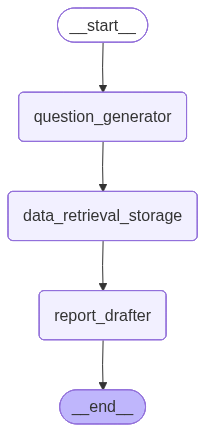

In [29]:
try:
    display(Image(competitive_analysis.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    print("some error")
    pass

# **Execution**

Invoking the workflow with the company  name as input.

[NODE]: run_question_generator
[INSIDE TOOL] suggest_questions
[Identified SECTOR] Automotive
[IS VALID COMPANY] True
[QUESTION GENERATED LIST] ["Who are Tesla's main competitors in the electric vehicle market, and what is their respective market share?", "How do Tesla's vehicle features, pricing, and technology compare to those of its key competitors?", "What are Tesla's strengths and weaknesses in terms of innovation, brand perception, and customer service compared to its rivals?", "What current market trends and regulatory challenges could impact Tesla's growth opportunities in the electric vehicle sector?", 'What strategies can Tesla implement to differentiate itself from competitors and enhance its market position, particularly in sustainability and partnerships?']
[PARSED OUTPUT]: sector=Automotive, is_valid_company=True, questions=["Who are Tesla's main competitors in the electric vehicle market, and what is their respective market share?", "How do Tesla's vehicle features, pric
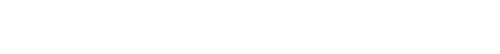

In [30]:
# sample input -> Tesla, Infosys, Deloitte, Great Learning
companyname = "Tesla"
# Invoke the workflow using the given company name
result = competitive_analysis.invoke({"company_name": companyname})

For better readability, displaying the report in Markdown format

In [31]:
display(Markdown(result['report']))

# Competitor Analysis Report: Tesla in the Automotive Sector

## Executive Summary
Tesla, a leader in the electric vehicle (EV) market, is recognized for its competitive pricing, superior range, and advanced technology. This report analyzes Tesla's position in the automotive sector, focusing on its key competitors, strengths and weaknesses, market strategies, and actionable recommendations. Despite facing challenges such as regulatory scrutiny and supply chain issues, Tesla's innovation and brand perception provide a solid foundation for future growth.

## Company Overview
Tesla, Inc. is an American electric vehicle and clean energy company founded in 2003. It specializes in electric vehicles, battery energy storage, and solar energy products. Tesla's mission is to accelerate the world's transition to sustainable energy, and it has established itself as a pioneer in the EV market.

## Key Competitors
Tesla's main competitors in the EV market include:
- **Chevrolet**: 15.2% market share
- **Ford**: 5.5% market share
- **Hyundai**: 5.3% market share
- **Xiaomi**: New entrant with the SU7 sedan in 2024

### Competitive Comparison
- **Pricing**: Tesla's vehicles are often priced competitively, offering better performance and longer range at lower price points compared to the Ford Mustang Mach-E and Chevrolet Bolt EV.
- **Technology**: Tesla is known for its advanced technology, including Autopilot and over-the-air software updates, which enhance user experience and vehicle performance.
- **Performance**: Tesla models consistently outperform competitors in terms of acceleration, range, and overall driving experience.

## Strengths and Weaknesses
### Strengths
- **Innovation**: Tesla excels in technological advancements and product innovation, maintaining a strong lead in the EV market.
- **Brand Perception**: Tesla has cultivated a strong brand image associated with sustainability and cutting-edge technology.
- **Market Leadership**: As a pioneer in the EV sector, Tesla enjoys significant market share and consumer loyalty.

### Weaknesses
- **Global Operations**: Tesla faces challenges in managing its global operations, which can lead to inefficiencies.
- **Customer Service**: Compared to rivals, Tesla has received criticism regarding its customer service, which could impact customer retention.
- **Regulatory Scrutiny**: The company is subject to increasing regulatory scrutiny and potential new rules in key markets, which could hinder growth.

## Market Strategies
Tesla's strategic focus includes:
- **Expansion**: Aiming to grow its presence in North America, Europe, China, and emerging markets.
- **Sustainability**: Emphasizing sustainability and green technologies to align with global trends and consumer preferences.
- **Partnerships**: Forming strategic alliances with governments and businesses to promote sustainable transport and enhance market position.

## Recommendations
1. **Enhance Customer Service**: Invest in improving customer service operations to address existing gaps and enhance customer satisfaction.
2. **Leverage Strategic Partnerships**: Pursue collaborations with governments and businesses to bolster Tesla's sustainability initiatives and drive innovation.
3. **Focus on Emerging Markets**: Prioritize expansion efforts in emerging markets where EV adoption is on the rise, tailoring products to meet local needs.
4. **Monitor Regulatory Changes**: Stay ahead of regulatory developments to mitigate risks associated with compliance and adapt strategies accordingly.
5. **Innovate Continuously**: Maintain a strong focus on R&D to ensure Tesla remains at the forefront of technological advancements in the EV sector.

## Conclusion
Tesla's competitive advantages in pricing, technology, and brand perception position it well within the automotive sector. However, addressing weaknesses in customer service and navigating regulatory challenges will be crucial for sustaining growth. By implementing the recommended strategies, Tesla can enhance its market position and continue to lead the electric vehicle revolution.